# New Brunswick Economic Analytics  
## Analyse socio-économique du Nouveau-Brunswick avec SQL

### Projet Data Analytics — SQL

Ce projet analyse plusieurs dimensions économiques et démographiques du Nouveau-Brunswick à partir de trois jeux de données :

- la population et le logement ;
- le marché du travail ;
- le revenu des ménages.

L’objectif est d’utiliser SQL pour explorer les données, vérifier leur qualité, identifier les principales tendances et croiser plusieurs indicateurs économiques.

### Compétences SQL utilisées

- SELECT, WHERE, ORDER BY
- GROUP BY et fonctions d’agrégation
- CASE WHEN
- JOIN
- sous-requêtes
- Common Table Expressions (CTE)
- fonctions fenêtres : LAG(), ROW_NUMBER(), RANK()
- création de vues SQL
- préparation de requêtes pour la visualisation et les tableaux de bord

# Environnement de travail

In [30]:
import sqlite3
import pandas as pd

# Partie 1 – Création de la base de données
Avant de pouvoir interroger quoi que ce soit, il nous faut… des données ! Dans la vraie vie, la base de données économique du Nouveau‑Brunswick
existerait déjà : elle serait alimentée par Statistique Canada, les ministères provinciaux et d’autres sources officielles. 
Ici, nous allons la reconstituer nous‑mêmes à partir de trois fichiers CSV, qui contiennent des séries temporelles et des données régionales.

### Structure de la base de données

La base SQLite utilisée dans ce projet est construite à partir de trois jeux de données complémentaires :

- **population_logement_nb** : informations démographiques et territoriales des régions du Nouveau-Brunswick ;
- **marche_travail_nb** : évolution annuelle de l'emploi, du chômage et de la population active ;
- **revenu_menages_nb** : évolution annuelle des revenus au Nouveau-Brunswick.

Les tables `marche_travail_nb` et `revenu_menages_nb` peuvent être croisées grâce à la variable commune `annee`.
### Schéma des données

Les trois tables représentent deux dimensions complémentaires de l'économie du Nouveau-Brunswick : une dimension régionale et démographique, 
et une dimension temporelle et économique.

Les tables `marche_travail_nb` et `revenu_menages_nb` sont reliées logiquement par la variable `annee`, 
ce qui permettra de réaliser des analyses croisées avec SQL.

### Schéma de la base de données

![Schéma de la base de données](C:\Users\Utilisateur\Desktop\NewBrunswick-Economic-Analytics\image/database_schema.png)


### 1.1 Connexion à la base de données SQLite

Nous allons maintenant créer une connexion à la base de données SQLite utilisée pour l'analyse.

La base sera enregistrée dans le dossier `database` du projet afin de conserver les données
de manière persistante et de pouvoir réutiliser la même base lors des différentes étapes de l'analyse.

In [31]:
import os
import sqlite3

# Chemin principal du projet
project_path = r"C:\Users\Utilisateur\Desktop\NewBrunswick-Economic-Analytics"

# Chemin vers la base de données
database_path = os.path.join(
    project_path,
    "database",
    "new_brunswick_economic.db"
)

# Connexion SQLite
conn = sqlite3.connect(database_path)
cursor = conn.cursor()

print("Connexion à la base de données réussie.")
print("Base :", database_path)

Connexion à la base de données réussie.
Base : C:\Users\Utilisateur\Desktop\NewBrunswick-Economic-Analytics\database\new_brunswick_economic.db


### 1.2 Création des tables

Nous allons maintenant créer les trois tables principales de la base de données :

- `population_logement_nb`
- `marche_travail_nb`
- `revenu_menages_nb`

La structure des tables reprend les types de données et les clés définis dans le projet SQL.

In [4]:
# Chemin vers le script SQL de création des tables
sql_file_path = os.path.join(
    project_path,
    "sql",
    "01_create_tables.sql"
)

# Lecture du fichier SQL
with open(sql_file_path, "r", encoding="utf-8") as file:
    create_tables_sql = file.read()

# Exécution du script SQL
cursor.executescript(create_tables_sql)

# Sauvegarde des modifications
conn.commit()

print("Les tables ont été créées avec succès.")

Les tables ont été créées avec succès.


### 1.3 Vérification de la structure de la base

Avant d'importer les données, nous vérifions que les trois tables ont bien été créées dans SQLite.

In [5]:
# Vérification des tables présentes dans la base
query = """
SELECT name
FROM sqlite_master
WHERE type = 'table'
ORDER BY name;
"""

tables = pd.read_sql_query(query, conn)

tables

,name
0,marche_travail_nb
1,population_logement_nb
2,revenu_menages_nb


### 1.4 Préparation de l'import des fichiers CSV

Les trois jeux de données sources sont stockés dans le dossier `data` du projet.

Avant de les charger dans SQLite, nous vérifions les noms exacts des fichiers disponibles.

In [6]:
# Chemin vers le dossier contenant les fichiers CSV
data_path = os.path.join(project_path, "data")

# Affichage des fichiers disponibles
os.listdir(data_path)

['marche_travail_nb.csv',
 'population_logement_nb.csv',
 'revenu_menages_nb.csv']

### 1.5 Import des données CSV dans SQLite

Nous allons maintenant charger les trois fichiers CSV dans les tables correspondantes de la base de données.

Les fichiers sont lus avec Pandas, puis insérés dans SQLite.

In [7]:
# Chemin vers le dossier des données
data_path = os.path.join(project_path, "data")

# Chargement des trois fichiers CSV
df_population = pd.read_csv(
    os.path.join(data_path, "population_logement_nb.csv")
)

df_marche = pd.read_csv(
    os.path.join(data_path, "marche_travail_nb.csv")
)

df_revenu = pd.read_csv(
    os.path.join(data_path, "revenu_menages_nb.csv")
)

print("Fichiers CSV chargés avec succès.")
print("Population/Logement :", len(df_population), "lignes")
print("Marché du travail    :", len(df_marche), "lignes")
print("Revenu des ménages   :", len(df_revenu), "lignes")

Fichiers CSV chargés avec succès.
Population/Logement : 200 lignes
Marché du travail    : 31 lignes
Revenu des ménages   : 26 lignes


### 1.6 Vérification de la structure des fichiers

Avant l'import dans SQLite, nous vérifions les colonnes de chaque jeu de données afin de nous assurer 
qu'elles correspondent à la structure des tables créées.

In [8]:
print("Colonnes — Population / Logement")
print(df_population.columns.tolist())

print("\nColonnes — Marché du travail")
print(df_marche.columns.tolist())

print("\nColonnes — Revenu des ménages")
print(df_revenu.columns.tolist())

Colonnes — Population / Logement
['nom_geographique', 'type_region', 'population_2021', 'population_2016', 'variation_population_2016_2021_pct', 'logements_prives_2021', 'logements_prives_2016', 'variation_logements_prives_2016_2021_pct', 'logements_occupes_2021', 'logements_occupes_2016', 'variation_logements_occupes_2016_2021_pct', 'superficie_km2_2021', 'densite_population_km2_2021', 'classement_national_population_2021', 'classement_nb_population_2021']

Colonnes — Marché du travail
['annee', 'population_15_plus_milliers', 'population_active_milliers', 'emploi_milliers', 'chomage_milliers', 'taux_chomage_pct', 'taux_activite_pct', 'taux_emploi_pct']

Colonnes — Revenu des ménages
['annee', 'remuneration_salaries_millions_cad', 'revenu_mixte_net_millions_cad', 'revenu_propriete_recu_millions_cad', 'transferts_courants_recus_millions_cad', 'revenu_total_millions_cad']


### 1.7 Vérification de la compatibilité avec les tables SQLite

Avant d'insérer les données, nous comparons la structure des fichiers CSV avec celle des tables SQLite.

Cette vérification permet d'éviter les erreurs d'import et de préserver les types de données, les clés primaires
et les contraintes définies lors de la création de la base.

In [9]:
# Structure de la table population_logement_nb
schema_population = pd.read_sql_query(
    "PRAGMA table_info(population_logement_nb);",
    conn
)

# Structure de la table marche_travail_nb
schema_marche = pd.read_sql_query(
    "PRAGMA table_info(marche_travail_nb);",
    conn
)

# Structure de la table revenu_menages_nb
schema_revenu = pd.read_sql_query(
    "PRAGMA table_info(revenu_menages_nb);",
    conn
)

print("TABLE : population_logement_nb")
display(schema_population)

print("\nTABLE : marche_travail_nb")
display(schema_marche)

print("\nTABLE : revenu_menages_nb")
display(schema_revenu)

TABLE : population_logement_nb


,cid,name,type,notnull,dflt_value,pk
0,0,id,INTEGER,0,None,1
1,1,nom_geographique,TEXT,1,None,0
2,2,type_region,TEXT,0,None,0
3,3,population_2016,INTEGER,0,None,0
4,4,population_2021,INTEGER,0,None,0
5,5,variation_population_2016_2021_pct,REAL,0,None,0
6,6,logements_prives_2016,INTEGER,0,None,0
7,7,logements_prives_2021,INTEGER,0,None,0
8,8,variation_logements_prives_2016_2021_pct,REAL,0,None,0
9,9,logements_occupes_2016,INTEGER,0,None,0



TABLE : marche_travail_nb


,cid,name,type,notnull,dflt_value,pk
0,0,annee,INTEGER,0,None,1
1,1,population_15_plus_milliers,REAL,0,None,0
2,2,population_active_milliers,REAL,0,None,0
3,3,emploi_milliers,REAL,0,None,0
4,4,chomage_milliers,REAL,0,None,0
5,5,taux_chomage_pct,REAL,0,None,0
6,6,taux_activite_pct,REAL,0,None,0
7,7,taux_emploi_pct,REAL,0,None,0



TABLE : revenu_menages_nb


,cid,name,type,notnull,dflt_value,pk
0,0,annee,INTEGER,0,None,1
1,1,remuneration_salaries_millions_cad,REAL,0,None,0
2,2,revenu_mixte_net_millions_cad,REAL,0,None,0
3,3,revenu_propriete_recu_millions_cad,REAL,0,None,0
4,4,transferts_courants_recus_millions_cad,REAL,0,None,0
5,5,revenu_total_millions_cad,REAL,0,None,0


### 1.8 Import des données dans SQLite

Les données des trois fichiers CSV sont maintenant insérées dans les tables SQLite existantes.

Pour préserver la structure SQL déjà définie, notamment les clés primaires et les types de données, les tables ne sont pas remplacées.

Les deux colonnes de classement présentes dans le fichier de population mais absentes de la table SQLite sont exclues avant l'import.

In [10]:
# Préparation du DataFrame population pour correspondre à la table SQLite
df_population_sql = df_population.drop(
    columns=[
        "classement_national_population_2021",
        "classement_nb_population_2021"
    ]
)

# Réorganisation des colonnes selon la structure SQLite
df_population_sql = df_population_sql[
    [
        "nom_geographique",
        "type_region",
        "population_2016",
        "population_2021",
        "variation_population_2016_2021_pct",
        "logements_prives_2016",
        "logements_prives_2021",
        "variation_logements_prives_2016_2021_pct",
        "logements_occupes_2016",
        "logements_occupes_2021",
        "variation_logements_occupes_2016_2021_pct",
        "superficie_km2_2021",
        "densite_population_km2_2021"
    ]
]

# Import dans les tables SQLite existantes
df_population_sql.to_sql(
    "population_logement_nb",
    conn,
    if_exists="append",
    index=False
)

df_marche.to_sql(
    "marche_travail_nb",
    conn,
    if_exists="append",
    index=False
)

df_revenu.to_sql(
    "revenu_menages_nb",
    conn,
    if_exists="append",
    index=False
)

conn.commit()

print("Import terminé avec succès.")

Import terminé avec succès.


### 1.9 Vérification des données importées

Nous vérifions maintenant que les données ont bien été insérées dans les trois tables SQLite en
comptant le nombre d'enregistrements présents dans chacune d'elles.

query_counts = """
SELECT 'population_logement_nb' AS table_name, COUNT(*) AS nb_lignes
FROM population_logement_nb

UNION ALL

SELECT 'marche_travail_nb', COUNT(*)
FROM marche_travail_nb

UNION ALL

SELECT 'revenu_menages_nb', COUNT(*)
FROM revenu_menages_nb;
"""

pd.read_sql_query(query_counts, conn)

### 1.10 Aperçu des données

Après avoir vérifié le nombre d'enregistrements, nous affichons les cinq premières lignes de chaque table
afin de contrôler visuellement la structure et le contenu des données importées.

In [11]:
# Aperçu de la table population_logement_nb
print("Table : population_logement_nb")
display(
    pd.read_sql_query(
        "SELECT * FROM population_logement_nb LIMIT 5;",
        conn
    )
)

# Aperçu de la table marche_travail_nb
print("\nTable : marche_travail_nb")
display(
    pd.read_sql_query(
        "SELECT * FROM marche_travail_nb LIMIT 5;",
        conn
    )
)

# Aperçu de la table revenu_menages_nb
print("\nTable : revenu_menages_nb")
display(
    pd.read_sql_query(
        "SELECT * FROM revenu_menages_nb LIMIT 5;",
        conn
    )
)

Table : population_logement_nb


,id,nom_geographique,type_region,population_2016,population_2021,variation_population_2016_2021_pct,logements_prives_2016,logements_prives_2021,variation_logements_prives_2016_2021_pct,logements_occupes_2016,logements_occupes_2021,variation_logements_occupes_2016_2021_pct,superficie_km2_2021,densite_population_km2_2021
0,1,Bouctouche,TV,2361,2513,6.4,1179,1188,0.8,1071,1094,2.1,18.33,137.1
1,2,Buctouche 16,IRI,96,101,5.2,40,44,10.0,39,44,12.8,0.38,266.6
2,3,Carleton,P,708,764,7.9,404,413,2.2,332,359,8.1,435.23,1.8
3,4,Cocagne,RCR,2649,2757,4.1,1418,1430,0.8,1160,1214,4.7,69.23,39.8
4,5,Dundas,P,3914,4332,10.7,2529,2569,1.6,1690,1908,12.9,172.32,25.1



Table : marche_travail_nb


,annee,population_15_plus_milliers,population_active_milliers,emploi_milliers,chomage_milliers,taux_chomage_pct,taux_activite_pct,taux_emploi_pct
0,1993,582.2,343.2,299.9,43.3,12.6,58.9,51.5
1,1994,584.7,341.4,298.6,42.8,12.5,58.4,51.1
2,1995,587.2,347.2,307.5,39.7,11.4,59.1,52.4
3,1996,589.9,346.0,305.8,40.2,11.6,58.7,51.8
4,1997,592.6,354.9,310.1,44.8,12.6,59.9,52.3



Table : revenu_menages_nb


,annee,remuneration_salaries_millions_cad,revenu_mixte_net_millions_cad,revenu_propriete_recu_millions_cad,transferts_courants_recus_millions_cad,revenu_total_millions_cad
0,1997,8813.0,1695.0,1981.0,3239.0,15728.0
1,1998,9252.0,1778.0,2078.0,3388.0,16496.0
2,1999,9848.0,1840.0,2215.0,3424.0,17327.0
3,2000,10513.0,1851.0,2293.0,3428.0,18085.0
4,2001,10629.0,1932.0,2241.0,3757.0,18559.0


# Partie 2 — Contrôle qualité des données

Avant toute analyse, il est essentiel de vérifier la qualité des données.

Cette étape permet de s'assurer que les jeux de données sont cohérents, complets et exploitables avant de produire des résultats économiques.

Les contrôles réalisés portent sur :

- le nombre d'enregistrements ;
- les doublons ;
- les valeurs manquantes ;
- les valeurs négatives ou incohérentes ;
- la validité des taux exprimés en pourcentage.

### 2.1 Vérification du nombre d'enregistrements

Nous vérifions que le nombre de lignes présentes dans les trois tables correspond bien aux fichiers sources.

In [12]:
query = """
SELECT 'population_logement_nb' AS table_name, COUNT(*) AS row_count
FROM population_logement_nb

UNION ALL

SELECT 'marche_travail_nb', COUNT(*)
FROM marche_travail_nb

UNION ALL

SELECT 'revenu_menages_nb', COUNT(*)
FROM revenu_menages_nb;
"""

pd.read_sql_query(query, conn)

,table_name,row_count
0,population_logement_nb,200
1,marche_travail_nb,31
2,revenu_menages_nb,26


### 2.2 Recherche des doublons

Les doublons peuvent fausser les agrégations et les analyses statistiques.

Nous vérifions donc :

- les doublons géographiques dans la table de population ;
- les années dupliquées dans la table du marché du travail ;
- les années dupliquées dans la table des revenus.

In [13]:
# Doublons dans les données de population
query_duplicates_population = """
SELECT
    nom_geographique,
    type_region,
    COUNT(*) AS nombre_occurrences
FROM population_logement_nb
GROUP BY nom_geographique, type_region
HAVING COUNT(*) > 1;
"""

pd.read_sql_query(query_duplicates_population, conn)

,nom_geographique,type_region,nombre_occurrences


**Résultat :** aucun doublon géographique n'a été détecté dans la table `population_logement_nb`.

In [14]:
# Doublons dans la table du marché du travail
query_duplicates_marche = """
SELECT
    annee,
    COUNT(*) AS nombre_occurrences
FROM marche_travail_nb
GROUP BY annee
HAVING COUNT(*) > 1;
"""

print("Doublons — Marché du travail")
display(pd.read_sql_query(query_duplicates_marche, conn))


# Doublons dans la table des revenus
query_duplicates_revenu = """
SELECT
    annee,
    COUNT(*) AS nombre_occurrences
FROM revenu_menages_nb
GROUP BY annee
HAVING COUNT(*) > 1;
"""

print("Doublons — Revenu des ménages")
display(pd.read_sql_query(query_duplicates_revenu, conn))

Doublons — Marché du travail


,annee,nombre_occurrences


Doublons — Revenu des ménages


,annee,nombre_occurrences


**Résultat :** aucun doublon n'a été détecté dans les trois tables. Les observations géographiques sont uniques dans la
table de population et chaque année apparaît une seule fois dans les tables du marché du travail et des revenus.

### 2.3 Recherche des valeurs manquantes

Les valeurs manquantes peuvent affecter les calculs, les agrégations et l'interprétation des résultats.

Nous comptons donc les valeurs `NULL` présentes dans les principales variables de chaque table.

In [15]:
query_null_population = """
SELECT
    SUM(CASE WHEN nom_geographique IS NULL THEN 1 ELSE 0 END)
        AS null_nom_geographique,

    SUM(CASE WHEN type_region IS NULL THEN 1 ELSE 0 END)
        AS null_type_region,

    SUM(CASE WHEN population_2016 IS NULL THEN 1 ELSE 0 END)
        AS null_population_2016,

    SUM(CASE WHEN population_2021 IS NULL THEN 1 ELSE 0 END)
        AS null_population_2021,

    SUM(CASE WHEN variation_population_2016_2021_pct IS NULL THEN 1 ELSE 0 END)
        AS null_variation_population,

    SUM(CASE WHEN superficie_km2_2021 IS NULL THEN 1 ELSE 0 END)
        AS null_superficie,

    SUM(CASE WHEN densite_population_km2_2021 IS NULL THEN 1 ELSE 0 END)
        AS null_densite

FROM population_logement_nb;
"""

pd.read_sql_query(query_null_population, conn)

,null_nom_geographique,null_type_region,null_population_2016,null_population_2021,null_variation_population,null_superficie,null_densite
0,0,0,0,0,0,0,0


**Résultat :** aucune valeur manquante n'a été détectée dans les principales variables de la table `population_logement_nb`. Les 200 observations sont donc complètes pour les variables utilisées dans l'analyse.

In [16]:
# Valeurs NULL — Marché du travail
query_null_marche = """
SELECT
    SUM(CASE WHEN annee IS NULL THEN 1 ELSE 0 END) AS null_annee,
    SUM(CASE WHEN population_15_plus_milliers IS NULL THEN 1 ELSE 0 END) AS null_population_15_plus,
    SUM(CASE WHEN population_active_milliers IS NULL THEN 1 ELSE 0 END) AS null_population_active,
    SUM(CASE WHEN emploi_milliers IS NULL THEN 1 ELSE 0 END) AS null_emploi,
    SUM(CASE WHEN chomage_milliers IS NULL THEN 1 ELSE 0 END) AS null_chomage,
    SUM(CASE WHEN taux_chomage_pct IS NULL THEN 1 ELSE 0 END) AS null_taux_chomage,
    SUM(CASE WHEN taux_activite_pct IS NULL THEN 1 ELSE 0 END) AS null_taux_activite,
    SUM(CASE WHEN taux_emploi_pct IS NULL THEN 1 ELSE 0 END) AS null_taux_emploi
FROM marche_travail_nb;
"""

print("Valeurs manquantes — Marché du travail")
display(pd.read_sql_query(query_null_marche, conn))


# Valeurs NULL — Revenus
query_null_revenu = """
SELECT
    SUM(CASE WHEN annee IS NULL THEN 1 ELSE 0 END) AS null_annee,
    SUM(CASE WHEN remuneration_salaries_millions_cad IS NULL THEN 1 ELSE 0 END) AS null_remuneration,
    SUM(CASE WHEN revenu_mixte_net_millions_cad IS NULL THEN 1 ELSE 0 END) AS null_revenu_mixte,
    SUM(CASE WHEN revenu_propriete_recu_millions_cad IS NULL THEN 1 ELSE 0 END) AS null_revenu_propriete,
    SUM(CASE WHEN transferts_courants_recus_millions_cad IS NULL THEN 1 ELSE 0 END) AS null_transferts,
    SUM(CASE WHEN revenu_total_millions_cad IS NULL THEN 1 ELSE 0 END) AS null_revenu_total
FROM revenu_menages_nb;
"""

print("Valeurs manquantes — Revenu des ménages")
display(pd.read_sql_query(query_null_revenu, conn))

Valeurs manquantes — Marché du travail


,null_annee,null_population_15_plus,null_population_active,null_emploi,null_chomage,null_taux_chomage,null_taux_activite,null_taux_emploi
0,0,0,0,0,0,0,0,0


Valeurs manquantes — Revenu des ménages


,null_annee,null_remuneration,null_revenu_mixte,null_revenu_propriete,null_transferts,null_revenu_total
0,0,0,0,0,0,0


**Résultat :** aucune valeur manquante n'a été détectée dans les trois tables. Les données sont complètes pour
l'ensemble des variables utilisées dans l'analyse.

### 2.4 Vérification de la cohérence des valeurs

Au-delà des valeurs manquantes et des doublons, certaines valeurs peuvent être présentes mais incohérentes.

Nous vérifions notamment :

- l'absence de populations, d'emplois ou de revenus négatifs ;
- que les taux du marché du travail sont compris entre 0 % et 100 % ;
- que les superficies et densités de population ne sont pas négatives.

In [18]:
query_incoherences = """
SELECT
    (SELECT COUNT(*)
     FROM population_logement_nb
     WHERE population_2016 < 0
        OR population_2021 < 0
        OR superficie_km2_2021 < 0
        OR densite_population_km2_2021 < 0)
        AS anomalies_population,

    (SELECT COUNT(*)
     FROM marche_travail_nb
     WHERE population_active_milliers < 0
        OR emploi_milliers < 0
        OR chomage_milliers < 0)
        AS anomalies_marche_travail,

    (SELECT COUNT(*)
     FROM revenu_menages_nb
     WHERE remuneration_salaries_millions_cad < 0
        OR revenu_mixte_net_millions_cad < 0
        OR revenu_propriete_recu_millions_cad < 0
        OR transferts_courants_recus_millions_cad < 0
        OR revenu_total_millions_cad < 0)
        AS anomalies_revenus;
"""

pd.read_sql_query(query_incoherences, conn)

,anomalies_population,anomalies_marche_travail,anomalies_revenus
0,0,0,0


**Résultat :** aucune valeur négative incohérente n'a été détectée dans les variables démographiques, 
les indicateurs du marché du travail ou les données de revenus.

### 2.5 Vérification des taux du marché du travail

Les taux de chômage, d'activité et d'emploi étant exprimés en pourcentage, leurs valeurs doivent être comprises entre 0 % et 100 %.

Nous recherchons toute observation située en dehors de cet intervalle.

In [19]:
query_taux_invalides = """
SELECT
    annee,
    taux_chomage_pct,
    taux_activite_pct,
    taux_emploi_pct
FROM marche_travail_nb
WHERE taux_chomage_pct NOT BETWEEN 0 AND 100
   OR taux_activite_pct NOT BETWEEN 0 AND 100
   OR taux_emploi_pct NOT BETWEEN 0 AND 100;
"""

pd.read_sql_query(query_taux_invalides, conn)

,annee,taux_chomage_pct,taux_activite_pct,taux_emploi_pct


### Conclusion du contrôle qualité

Les contrôles effectués montrent que les données sont de bonne qualité :

- aucun doublon détecté ;
- aucune valeur manquante dans les variables analysées ;
- aucune valeur négative incohérente ;
- tous les taux du marché du travail sont compris entre 0 % et 100 %.

Les trois jeux de données sont donc prêts pour l'analyse exploratoire et les analyses économiques.

# Partie 3 — Analyse démographique du Nouveau-Brunswick

Cette partie explore la répartition et l'évolution de la population du Nouveau-Brunswick entre 2016 et 2021.

Nous chercherons notamment à identifier :

- les régions les plus peuplées ;
- les régions ayant connu la plus forte croissance démographique ;
- les régions ayant enregistré les plus fortes baisses de population ;
- les territoires présentant les plus fortes densités de population.

### 3.1 Top 10 des régions les plus peuplées (2021)

Cette première requête identifie les territoires du Nouveau-Brunswick qui concentrent le plus d'habitants.

- **CT** = Comté, 
- **C** = Ville,
- **TV** = Ville (town),
- **RCR** = Région rurale communautaire,
- **IRI** = Réserve indienne.

In [20]:
query_top10_population = """
SELECT
    nom_geographique,
    type_region,
    population_2021
FROM population_logement_nb
ORDER BY population_2021 DESC
LIMIT 10;
"""

print("Régions les plus peuplées du Nouveau-Brunswick (2021)")
display(
    pd.read_sql_query(query_top10_population, conn)
)

Régions les plus peuplées du Nouveau-Brunswick (2021)


,nom_geographique,type_region,population_2021
0,Westmorland,CT,163576
1,York,CT,105261
2,Moncton,C,79470
3,Saint John,CT,76558
4,Kings,CT,71184
5,Saint John,C,69895
6,Fredericton5,C,63116
7,Northumberland,CT,45005
8,Madawaska,CT,32603
9,Restigouche,CT,30700


### 3.2 Top 10 des plus fortes croissances démographiques (2016 → 2021)

Le Nouveau-Brunswick a connu des dynamiques contrastées. On observe ici les régions qui ont attiré le plus de nouveaux habitants en 5 ans.

In [21]:
query_top10_croissance = """
SELECT
    nom_geographique,
    type_region,
    population_2016,
    population_2021,
    variation_population_2016_2021_pct
FROM population_logement_nb
WHERE variation_population_2016_2021_pct IS NOT NULL
ORDER BY variation_population_2016_2021_pct DESC
LIMIT 10;
"""

print("Régions avec la plus forte croissance 2016-2021 (%)")
display(
    pd.read_sql_query(query_top10_croissance, conn)
)

Régions avec la plus forte croissance 2016-2021 (%)


,nom_geographique,type_region,population_2016,population_2021,variation_population_2016_2021_pct
0,Renous 124,IRI,5,10,100.0
1,Tabusintac 9,IRI,10,20,100.0
2,St. Basile 10,IRI,214,369,72.4
3,Indian Ranch,IRI,89,134,50.6
4,Red Bank 4,IRI,309,400,29.4
5,Cambridge-Narrows,VL,562,715,27.2
6,Saint-Basile,P,592,736,24.3
7,North Lake,P,233,282,21.0
8,Big Hole Tract 8 (North Half)4,IRI,25,30,20.0
9,Dumfries,P,356,420,18.0


**Interprétation :** les plus fortes variations relatives concernent principalement des territoires de petite taille démographique. Par exemple, Renous 124 et Tabusintac 9 affichent une croissance de 100 %, mais leurs populations passent respectivement de 5 à 10 habitants et de 10 à 20 habitants.

St. Basile 10 présente une évolution plus significative en volume, avec une population passant de 214 à 369 habitants, soit une hausse de 72,4 %.

Ces résultats montrent l'importance de considérer simultanément le taux de croissance et la taille de la population avant d'interpréter une évolution démographique.

### 3.3 Régions ayant enregistré les plus fortes baisses de population (2016 → 2021)

Analyser les baisses est tout aussi important. Cela peut indiquer des territoires en déclin économique ou des zones rurales touchées par l'exode.

In [22]:
query_top10_baisse = """
SELECT
    nom_geographique,
    type_region,
    population_2016,
    population_2021,
    variation_population_2016_2021_pct
FROM population_logement_nb
WHERE variation_population_2016_2021_pct IS NOT NULL
ORDER BY variation_population_2016_2021_pct ASC
LIMIT 10;
"""

print("Régions avec les plus fortes baisses 2016-2021 (%)")
display(
    pd.read_sql_query(query_top10_baisse, conn)
)

Régions avec les plus fortes baisses 2016-2021 (%)


,nom_geographique,type_region,population_2016,population_2021,variation_population_2016_2021_pct
0,Madawaska,P,10,0,-100.0
1,Huskisson,P,15,5,-66.7
2,Lorne,P,464,313,-32.5
3,Big Hole Tract 8 (South Half)4,IRI,23,16,-30.4
4,Indian Island 284,IRI,153,116,-24.2
5,Dorchester,VL,1096,906,-17.3
6,McAdam,P,73,61,-16.4
7,Meductic3,VL,215,180,-16.3
8,Saint-Léonard,P,975,858,-12.0
9,Durham,P,1076,950,-11.7


### 3.4 Top 10 des régions les plus densément peuplées (2021)

La densité est un indicateur crucial pour les infrastructures, les transports et l'urbanisme.

Nous calculons la densité directement (`population / superficie`) pour garantir le résultat, même si la colonne `densite_population_km2_2021` est déjà présente dans la table.

In [23]:
query_top10_densite = """
SELECT
    nom_geographique,
    type_region,
    population_2021,
    superficie_km2_2021,
    ROUND(population_2021 / superficie_km2_2021, 2) AS densite_calculee
FROM population_logement_nb
WHERE population_2021 IS NOT NULL
  AND superficie_km2_2021 > 0
ORDER BY densite_calculee DESC
LIMIT 10;
"""

print("Régions les plus densément peuplées (2021)")
display(
    pd.read_sql_query(query_top10_densite, conn)
)

Régions les plus densément peuplées (2021)


,nom_geographique,type_region,population_2021,superficie_km2_2021,densite_calculee
0,Moncton,C,79470,140.67,564.94
1,Saint-Quentin,TV,2141,4.24,504.95
2,Sussex,TV,4440,8.90,498.88
3,Saint-Louis de Kent,VL,981,1.98,495.45
4,Fredericton5,C,63116,133.93,471.26
5,Oromocto,TV,9045,22.36,404.52
6,Devon 30,IRI,1070,2.72,393.38
7,Campbellton,C,7047,18.57,379.48
8,Dieppe,C,28114,77.02,365.02
9,Rothesay,TV,11977,34.59,346.26


**Interprétation :** Moncton présente la densité de population la plus élevée parmi les territoires analysés, avec environ 565 habitants par km².

Cependant, la densité n'est pas directement liée à la taille totale de la population. Des municipalités beaucoup plus petites, comme Saint-Quentin, Sussex ou Saint-Louis de Kent, présentent également des densités élevées en raison de leur faible superficie.

Dieppe figure également parmi les dix territoires les plus densément peuplés, avec environ 365 habitants par km².

# Partie 4 — Analyse du marché du travail

Le marché du travail est un indicateur clé de la santé économique d’une province. Cette partie s’appuie sur la table `marche_travail_nb`, qui couvre une période de 1993 à 2023.

Nous allons explorer :

- l’évolution du taux de chômage et du taux d’emploi dans le temps ;
- les années les plus favorables et les plus difficiles pour l’emploi ;
- les variations d’une année sur l’autre (`LAG`) ;
- les tendances par décennie en utilisant `CASE WHEN` ;
- la relation entre activité et emploi.


In [24]:
query_overview = """
SELECT
    ROUND(AVG(taux_chomage_pct), 2) AS chomage_moyen_1993_2023,
    ROUND(MIN(taux_chomage_pct), 2) AS chomage_min,
    ROUND(MAX(taux_chomage_pct), 2) AS chomage_max,
    ROUND(AVG(taux_activite_pct), 2) AS activite_moyen,
    ROUND(AVG(taux_emploi_pct), 2) AS emploi_moyen
FROM marche_travail_nb;
"""

print("Indicateurs globaux (1993-2023)")
display(
    pd.read_sql_query(query_overview, conn)
)

Indicateurs globaux (1993-2023)


,chomage_moyen_1993_2023,chomage_min,chomage_max,activite_moyen,emploi_moyen
0,9.87,6.6,12.6,62.05,55.93


In [25]:
query_tendance_chomage = """
SELECT
    annee,
    taux_chomage_pct,
    LAG(taux_chomage_pct, 1) OVER (ORDER BY annee) AS chomage_annee_precedente,
    ROUND(taux_chomage_pct - LAG(taux_chomage_pct, 1) OVER (ORDER BY annee), 2) AS variation_annuelle_pct
FROM marche_travail_nb
ORDER BY annee;
"""

print("Évolution du taux de chômage et variation annuelle")
display(
    pd.read_sql_query(query_tendance_chomage, conn)
)

Évolution du taux de chômage et variation annuelle


,annee,taux_chomage_pct,chomage_annee_precedente,variation_annuelle_pct
0,1993,12.6,NaN,NaN
1,1994,12.5,12.6,-0.1
2,1995,11.4,12.5,-1.1
3,1996,11.6,11.4,0.2
4,1997,12.6,11.6,1.0
5,1998,12.2,12.6,-0.4
6,1999,10.2,12.2,-2.0
7,2000,10.0,10.2,-0.2
8,2001,11.1,10.0,1.1
9,2002,10.1,11.1,-1.0


In [26]:
query_meilleures_annees = """
SELECT
    annee,
    taux_chomage_pct,
    taux_activite_pct,
    taux_emploi_pct
FROM marche_travail_nb
ORDER BY taux_chomage_pct ASC
LIMIT 5;
"""

print("📈 Top 5 des années avec le plus faible taux de chômage")
display(
    pd.read_sql_query(query_meilleures_annees, conn)
)

query_pires_annees = """
SELECT
    annee,
    taux_chomage_pct,
    taux_activite_pct,
    taux_emploi_pct
FROM marche_travail_nb
ORDER BY taux_chomage_pct DESC
LIMIT 5;
"""

print("📉 Top 5 des années avec le plus fort taux de chômage")
display(
    pd.read_sql_query(query_pires_annees, conn)
)

📈 Top 5 des années avec le plus faible taux de chômage


,annee,taux_chomage_pct,taux_activite_pct,taux_emploi_pct
0,2023,6.6,60.5,56.6
1,2022,7.2,60.6,56.2
2,2007,7.7,63.8,58.9
3,2018,8.1,61.8,56.7
4,2019,8.2,61.6,56.6


📉 Top 5 des années avec le plus fort taux de chômage


,annee,taux_chomage_pct,taux_activite_pct,taux_emploi_pct
0,1993,12.6,58.9,51.5
1,1997,12.6,59.9,52.3
2,1994,12.5,58.4,51.1
3,1998,12.2,60.6,53.2
4,1996,11.6,58.7,51.8


In [27]:
query_par_decennie = """
SELECT
    CASE
        WHEN annee BETWEEN 1993 AND 1999 THEN '1993-1999'
        WHEN annee BETWEEN 2000 AND 2009 THEN '2000-2009'
        WHEN annee BETWEEN 2010 AND 2019 THEN '2010-2019'
        WHEN annee >= 2020 THEN '2020-2023'
    END AS periode,
    ROUND(AVG(taux_chomage_pct), 2) AS chomage_moyen,
    ROUND(AVG(taux_activite_pct), 2) AS activite_moyen,
    ROUND(AVG(taux_emploi_pct), 2) AS emploi_moyen,
    COUNT(*) AS nombre_annees
FROM marche_travail_nb
GROUP BY periode
ORDER BY periode;
"""

print("Comparaison des indicateurs par décennie")
display(
    pd.read_sql_query(query_par_decennie, conn)
)

Comparaison des indicateurs par décennie


,periode,chomage_moyen,activite_moyen,emploi_moyen,nombre_annees
0,1993-1999,11.87,59.49,52.43,7
1,2000-2009,9.55,63.39,57.32,10
2,2010-2019,9.42,62.99,57.05,10
3,2020-2023,8.32,60.85,55.80,4


# Partie 5 — Croisement marché du travail et revenu des ménages

Les deux tables `marche_travail_nb` et `revenu_menages_nb` partagent une colonne commune : `annee`. Cela nous permet de mettre en relation les indicateurs d’emploi avec les flux de revenus (salaires, revenu mixte, propriété, transferts).

Dans cette partie, nous allons :

- analyser la corrélation entre chômage et revenu total ;
- suivre l’évolution du revenu par actif (productivité apparente) ;
- mesurer le poids des transferts sociaux dans le revenu total ;
- observer les tendances sur la période commune 1997‑2023.

Ces requêtes mobilisent des compétences avancées : `JOIN`, calcul de ratios, `LAG`, et agrégations conditionnelles.

### 5.1 Connexion des deux séries temporelles (1997-2023)

In [35]:
query_jointure_globale = """
SELECT
    t.annee,
    t.taux_chomage_pct,
    t.taux_emploi_pct,
    t.population_active_milliers,
    r.revenu_total_millions_cad,
    r.remuneration_salaries_millions_cad,
    r.transferts_courants_recus_millions_cad
FROM marche_travail_nb t
JOIN revenu_menages_nb r ON t.annee = r.annee
ORDER BY t.annee;
"""

print("Série commune 1997-2023 (chômage, emploi, revenu total, salaires, transferts)")
display(
    pd.read_sql_query(query_jointure_globale, conn)
)

Série commune 1997-2023 (chômage, emploi, revenu total, salaires, transferts)


,annee,taux_chomage_pct,taux_emploi_pct,population_active_milliers,revenu_total_millions_cad,remuneration_salaries_millions_cad,transferts_courants_recus_millions_cad
0,1997,12.6,52.3,354.9,15728.0,8813.0,3239.0
1,1998,12.2,53.2,359.9,16496.0,9252.0,3388.0
2,1999,10.2,54.7,362.5,17327.0,9848.0,3424.0
3,2000,10.0,55.4,368.4,18085.0,10513.0,3428.0
4,2001,11.1,55.0,371.1,18559.0,10629.0,3757.0
5,2002,10.1,56.9,380.5,19043.0,11174.0,3817.0
6,2003,10.2,56.6,380.6,19636.0,11692.0,3980.0
7,2004,9.8,57.5,385.9,20485.0,12252.0,4177.0
8,2005,9.7,57.1,383.5,21163.0,12703.0,4250.0
9,2006,9.2,57.6,385.0,22364.0,13310.0,4602.0


### 5.2 Évolution du revenu total et du taux de chômage

In [34]:
query_revenu_vs_chomage = """
SELECT
    t.annee,
    t.taux_chomage_pct,
    ROUND(r.revenu_total_millions_cad, 1) AS revenu_total,
    ROUND(r.revenu_total_millions_cad - LAG(r.revenu_total_millions_cad, 1) OVER (ORDER BY t.annee), 1) AS variation_revenu_annuel,
    ROUND(
        (r.revenu_total_millions_cad - LAG(r.revenu_total_millions_cad, 1) OVER (ORDER BY t.annee))
        / LAG(r.revenu_total_millions_cad, 1) OVER (ORDER BY t.annee) * 100, 2
    ) AS pct_variation_revenu
FROM marche_travail_nb t
JOIN revenu_menages_nb r ON t.annee = r.annee
ORDER BY t.annee;
"""

print("Évolution du revenu total et variation annuelle en %")
display(
    pd.read_sql_query(query_revenu_vs_chomage, conn)
)

Évolution du revenu total et variation annuelle en %


,annee,taux_chomage_pct,revenu_total,variation_revenu_annuel,pct_variation_revenu
0,1997,12.6,15728.0,NaN,NaN
1,1998,12.2,16496.0,768.0,4.88
2,1999,10.2,17327.0,831.0,5.04
3,2000,10.0,18085.0,758.0,4.37
4,2001,11.1,18559.0,474.0,2.62
5,2002,10.1,19043.0,484.0,2.61
6,2003,10.2,19636.0,593.0,3.11
7,2004,9.8,20485.0,849.0,4.32
8,2005,9.7,21163.0,678.0,3.31
9,2006,9.2,22364.0,1201.0,5.67


### 5.3 Revenu total rapporté à la population active

In [37]:
query_revenu_par_actif = """
SELECT
    t.annee,
    ROUND(t.population_active_milliers, 1) AS actifs_milliers,
    ROUND(r.revenu_total_millions_cad, 1) AS revenu_total,
    ROUND(r.revenu_total_millions_cad / t.population_active_milliers, 2) AS revenu_par_actif_milliers_cad,
    ROUND(
        (r.revenu_total_millions_cad / t.population_active_milliers) 
        - LAG(r.revenu_total_millions_cad / t.population_active_milliers, 1) OVER (ORDER BY t.annee), 2
    ) AS variation_revenu_par_actif
FROM marche_travail_nb t
JOIN revenu_menages_nb r ON t.annee = r.annee
ORDER BY t.annee;
"""

print("Revenu total rapporté à la population active (milliers CAD par actif) - 1997 à 2022")
display(
    pd.read_sql_query(query_revenu_par_actif, conn)
)

Revenu total rapporté à la population active (milliers CAD par actif) - 1997 à 2022


,annee,actifs_milliers,revenu_total,revenu_par_actif_milliers_cad,variation_revenu_par_actif
0,1997,354.9,15728.0,44.32,NaN
1,1998,359.9,16496.0,45.83,1.52
2,1999,362.5,17327.0,47.80,1.96
3,2000,368.4,18085.0,49.09,1.29
4,2001,371.1,18559.0,50.01,0.92
5,2002,380.5,19043.0,50.05,0.04
6,2003,380.6,19636.0,51.59,1.54
7,2004,385.9,20485.0,53.08,1.49
8,2005,383.5,21163.0,55.18,2.10
9,2006,385.0,22364.0,58.09,2.90


In [ ]:
### 5.4 Poids des transferts sociaux dans le revenu total

In [39]:
query_poids_transferts = """
SELECT
    annee,
    ROUND(transferts_courants_recus_millions_cad, 1) AS transferts,
    ROUND(revenu_total_millions_cad, 1) AS revenu_total,
    ROUND(transferts_courants_recus_millions_cad / revenu_total_millions_cad * 100, 2) AS part_transferts_pct,
    ROUND(
        (transferts_courants_recus_millions_cad / revenu_total_millions_cad)
        - LAG(transferts_courants_recus_millions_cad / revenu_total_millions_cad, 1) OVER (ORDER BY annee),
        4
    ) * 100 AS variation_part_transferts_points
FROM revenu_menages_nb
ORDER BY annee;
"""

print("Part des transferts dans le revenu total (%)")
display(
    pd.read_sql_query(query_poids_transferts, conn)
)

Part des transferts dans le revenu total (%)


,annee,transferts,revenu_total,part_transferts_pct,variation_part_transferts_points
0,1997,3239.0,15728.0,20.59,NaN
1,1998,3388.0,16496.0,20.54,-0.06
2,1999,3424.0,17327.0,19.76,-0.78
3,2000,3428.0,18085.0,18.95,-0.81
4,2001,3757.0,18559.0,20.24,1.29
5,2002,3817.0,19043.0,20.04,-0.20
6,2003,3980.0,19636.0,20.27,0.22
7,2004,4177.0,20485.0,20.39,0.12
8,2005,4250.0,21163.0,20.08,-0.31
9,2006,4602.0,22364.0,20.58,0.50


### 5.5 Comparaison : chômage, revenu et transferts

In [42]:
query_vue_synthese = """
SELECT
    t.annee,
    t.taux_chomage_pct,
    ROUND(r.revenu_total_millions_cad, 1) AS revenu_total_millions,
    ROUND(r.transferts_courants_recus_millions_cad, 1) AS transferts_millions,
    ROUND(r.transferts_courants_recus_millions_cad / r.revenu_total_millions_cad * 100, 1) AS part_transferts_pct,
    ROUND(r.revenu_total_millions_cad / t.population_active_milliers, 2) AS revenu_par_actif_milliers_cad
FROM marche_travail_nb t
JOIN revenu_menages_nb r ON t.annee = r.annee
ORDER BY t.annee;
"""

print("Synthèse annuelle : chômage, revenu total, part des transferts et revenu par actif")
display(
    pd.read_sql_query(query_vue_synthese, conn)
)

Synthèse annuelle : chômage, revenu total, part des transferts et revenu par actif


,annee,taux_chomage_pct,revenu_total_millions,transferts_millions,part_transferts_pct,revenu_par_actif_milliers_cad
0,1997,12.6,15728.0,3239.0,20.6,44.32
1,1998,12.2,16496.0,3388.0,20.5,45.83
2,1999,10.2,17327.0,3424.0,19.8,47.80
3,2000,10.0,18085.0,3428.0,19.0,49.09
4,2001,11.1,18559.0,3757.0,20.2,50.01
5,2002,10.1,19043.0,3817.0,20.0,50.05
6,2003,10.2,19636.0,3980.0,20.3,51.59
7,2004,9.8,20485.0,4177.0,20.4,53.08
8,2005,9.7,21163.0,4250.0,20.1,55.18
9,2006,9.2,22364.0,4602.0,20.6,58.09


### 🔍 Interprétation:Croisement marché du travail et revenus

L'analyse croisée des données du marché du travail et des revenus met en évidence une évolution économique marquée au Nouveau-Brunswick entre 1997 et 2022.

Sur l'ensemble de la période, le **revenu total** passe de 15 728 à 40 862 millions CAD, soit une hausse d'environ **160 %**, tandis que le **taux de chômage** diminue globalement de 12,6 % à 7,2 %. Le revenu total rapporté à la population active progresse également fortement, passant de **44,32 à 101,52 milliers CAD par actif**.

L'année **2020** se distingue nettement du reste de la série. Le taux de chômage augmente de 8,2 % à 10,3 %, mais le revenu total continue de progresser. Dans le même temps, les transferts courants atteignent 10 940 millions CAD et représentent **29,7 % du revenu total**, contre 25,0 % en 2019.

À partir de 2021, la situation évolue progressivement : la part des transferts diminue à 27,2 %, puis à **24,6 % en 2022**, tandis que le chômage recule jusqu'à **7,2 %** et que le revenu total atteint son niveau le plus élevé de la série.

Ces résultats montrent l'intérêt de croiser plusieurs indicateurs économiques plutôt que de les analyser séparément. Les requêtes utilisant `JOIN`, `LAG` et les calculs de ratios permettent notamment d'identifier les tendances de long terme et les années atypiques. Les relations observées restent toutefois descriptives et ne permettent pas, à elles seules, d'établir des liens de causalité.

# Partie 6: Analyse régionale avancée

Après avoir étudié les principales tendances démographiques, cette partie approfondit l'analyse territoriale selon les différents types de régions présents dans la base.

Les données comprennent plusieurs niveaux géographiques. Certains territoires, notamment les comtés (`CT`), englobent d'autres unités géographiques telles que des villes, villages ou paroisses. Les agrégations doivent donc être interprétées avec prudence afin d'éviter les doubles comptages.

Nous allons principalement utiliser :

- `GROUP BY` et les fonctions d'agrégation (`COUNT`, `AVG`, `SUM`) ;
- `CASE WHEN` pour créer des catégories territoriales ;
- `RANK()` et `PARTITION BY` pour comparer des territoires similaires ;
- des filtres permettant de limiter certains biais liés à la taille des populations.

### 6.1 Profil démographique par type de région

In [46]:
query_repartition_type = """
SELECT
    type_region,
    COUNT(*) AS nombre_territoires,
    ROUND(AVG(population_2021), 0) AS population_moyenne,
    ROUND(AVG(superficie_km2_2021), 2) AS superficie_moyenne_km2,
    ROUND(AVG(densite_population_km2_2021), 2) AS densite_moyenne
FROM population_logement_nb
GROUP BY type_region
ORDER BY population_moyenne DESC;
"""

print("Profil démographique moyen par type de région (2021)")
display(
    pd.read_sql_query(query_repartition_type, conn)
)

Profil démographique moyen par type de région (2021)


,type_region,nombre_territoires,population_moyenne,superficie_moyenne_km2,densite_moyenne
0,CT,10,58206.0,5343.03,16.36
1,C,7,40253.0,138.80,322.11
2,TV,15,5601.0,28.14,247.17
3,RCR,7,3413.0,534.63,16.81
4,P,101,1603.0,505.49,6.33
5,VL,42,1274.0,31.36,99.02
6,IRI,18,465.0,7.84,135.40


### 6.2 Classement des régions par densité au sein de leur type

In [49]:
query_rank_par_type = """
WITH classement_densite AS (
    SELECT
        nom_geographique,
        type_region,
        population_2021,
        superficie_km2_2021,
        densite_population_km2_2021,
        RANK() OVER (
            PARTITION BY type_region
            ORDER BY densite_population_km2_2021 DESC
        ) AS rang_densite_dans_type
    FROM population_logement_nb
    WHERE densite_population_km2_2021 IS NOT NULL
      AND population_2021 > 0
)

SELECT
    nom_geographique,
    type_region,
    population_2021,
    superficie_km2_2021,
    densite_population_km2_2021,
    rang_densite_dans_type
FROM classement_densite
WHERE rang_densite_dans_type <= 3
ORDER BY type_region, rang_densite_dans_type;
"""

print("Top 3 des territoires les plus denses par type")
display(
    pd.read_sql_query(query_rank_par_type, conn)
)

Top 3 des territoires les plus denses par type


,nom_geographique,type_region,population_2021,superficie_km2_2021,densite_population_km2_2021,rang_densite_dans_type
0,Moncton,C,79470,140.67,564.9,1
1,Fredericton5,C,63116,133.93,471.3,2
2,Campbellton,C,7047,18.57,379.5,3
3,Saint John,CT,76558,1461.05,52.4,1
4,Westmorland,CT,163576,3659.74,44.7,2
5,Kings,CT,71184,3482.35,20.4,3
6,Devon 30,IRI,1070,2.72,393.4,1
7,Indian Island 284,IRI,116,0.40,288.8,2
8,Buctouche 16,IRI,101,0.38,266.6,3
9,Lincoln,P,7519,159.44,47.2,1


### 6.3 Comparaison Urbain / Rural / Autochtone

In [52]:
query_urbain_vs_rural = """
SELECT
    CASE
        WHEN type_region IN ('C', 'TV', 'VL') THEN 'Urbain'
        WHEN type_region IN ('P', 'RCR') THEN 'Rural'
        WHEN type_region = 'IRI' THEN 'Autochtone'
        ELSE 'Autre'
    END AS categorie,
    COUNT(*) AS nombre_territoires,
    ROUND(AVG(population_2021), 0) AS population_moyenne,
    ROUND(AVG(variation_population_2016_2021_pct), 2) AS variation_moyenne_pct,
    ROUND(AVG(densite_population_km2_2021), 2) AS densite_moyenne
FROM population_logement_nb
WHERE type_region <> 'CT'
GROUP BY categorie
ORDER BY population_moyenne DESC;
"""

print("Comparaison des profils Urbain / Rural / Autochtone")
display(
    pd.read_sql_query(query_urbain_vs_rural, conn)
)

Comparaison des profils Urbain / Rural / Autochtone


,categorie,nombre_territoires,population_moyenne,variation_moyenne_pct,densite_moyenne
0,Urbain,64,6551.0,2.09,158.14
1,Rural,108,1721.0,1.21,7.01
2,Autochtone,18,465.0,19.65,135.40


### 6.4 Top 10 des territoires avec la plus forte croissance

In [51]:
query_top10_croissance_filtre = """
SELECT
    nom_geographique,
    type_region,
    population_2016,
    population_2021,
    variation_population_2016_2021_pct
FROM population_logement_nb
WHERE variation_population_2016_2021_pct IS NOT NULL
  AND population_2016 >= 100
ORDER BY variation_population_2016_2021_pct DESC
LIMIT 10;
"""

print("Top 10 des territoires avec la plus forte croissance (population 2016 ≥ 100)")
display(
    pd.read_sql_query(query_top10_croissance_filtre, conn)
)

Top 10 des territoires avec la plus forte croissance (population 2016 ≥ 100)


,nom_geographique,type_region,population_2016,population_2021,variation_population_2016_2021_pct
0,St. Basile 10,IRI,214,369,72.4
1,Red Bank 4,IRI,309,400,29.4
2,Cambridge-Narrows,VL,562,715,27.2
3,Saint-Basile,P,592,736,24.3
4,North Lake,P,233,282,21.0
5,Dumfries,P,356,420,18.0
6,Colborne,P,227,266,17.2
7,Prince William,P,930,1083,16.5
8,Kars,P,325,377,16.0
9,St. Martins,VL,276,320,15.9


### 6.5 Occupation des logements par catégorie territoriale

Cette dernière analyse compare le nombre de logements privés et de logements occupés en 2021 selon les grandes catégories territoriales.

Les comtés (`CT`) sont exclus afin d'éviter de les agréger avec les unités géographiques qu'ils englobent.

Le taux d'occupation est calculé comme le rapport entre les **logements occupés** et l'ensemble des **logements privés**.

In [53]:
query_logements_par_categorie = """
SELECT
    CASE
        WHEN type_region IN ('C', 'TV', 'VL') THEN 'Urbain'
        WHEN type_region IN ('P', 'RCR') THEN 'Rural'
        WHEN type_region = 'IRI' THEN 'Autochtone'
        ELSE 'Autre'
    END AS categorie,
    SUM(logements_occupes_2021) AS logements_occupes_2021,
    SUM(logements_prives_2021) AS logements_prives_2021,
    ROUND(
        SUM(logements_occupes_2021) * 100.0 /
        NULLIF(SUM(logements_prives_2021), 0),
        2
    ) AS taux_occupation_pct
FROM population_logement_nb
WHERE type_region <> 'CT'
GROUP BY categorie
ORDER BY taux_occupation_pct DESC;
"""

print("Occupation des logements par catégorie territoriale (2021)")
display(
    pd.read_sql_query(query_logements_par_categorie, conn)
)

Occupation des logements par catégorie territoriale (2021)


,categorie,logements_occupes_2021,logements_prives_2021,taux_occupation_pct
0,Autochtone,3228,3399,94.97
1,Urbain,183998,195026,94.35
2,Rural,78667,89405,87.99


### 🔍 Interprétation: Analyse régionale 
L'analyse territoriale met en évidence des différences importantes entre les différents types de régions du Nouveau-Brunswick.

Les **villes (`C`)** présentent la densité moyenne la plus élevée, avec **322,11 habitants par km²**, tandis que les paroisses (`P`) affichent une densité moyenne beaucoup plus faible, de seulement **6,33 habitants par km²**. Les territoires classés comme urbains présentent ainsi une densité moyenne de **158,14 habitants par km²**, contre seulement **7,01** pour les territoires ruraux.

Le classement réalisé avec `RANK()` et `PARTITION BY` permet d'affiner cette comparaison à l'intérieur de chaque type de territoire. **Moncton** est la ville la plus dense avec **564,9 habitants par km²**. Parmi les `TV`, **Saint-Quentin** arrive en tête avec **504,7 habitants par km²**, tandis que **Saint-Louis de Kent** occupe la première position parmi les villages (`VL`) avec **494,6 habitants par km²**.

L'analyse de la croissance démographique montre également des écarts importants. Après exclusion des territoires comptant moins de 100 habitants en 2016, **St. Basile 10** présente la plus forte croissance relative, avec une population passant de 214 à 369 habitants, soit **+72,4 %**. Il est suivi de **Red Bank 4 (+29,4 %)** et de **Cambridge-Narrows (+27,2 %)**. Plusieurs paroisses figurent également parmi les dix territoires ayant enregistré les plus fortes progressions.

La comparaison des grandes catégories territoriales indique une croissance moyenne de **2,09 % en milieu urbain** et de **1,21 % en milieu rural**. La moyenne de **19,65 % observée pour les territoires autochtones** doit cependant être interprétée avec prudence, car les variations relatives peuvent être fortement influencées par la petite taille de certaines populations.

Enfin, l'analyse des logements montre des taux d'occupation élevés mais différenciés : **94,97 % dans les territoires autochtones**, **94,35 % dans les territoires urbains** et **87,99 % dans les territoires ruraux**.

Dans l'ensemble, cette analyse met en évidence une forte hétérogénéité territoriale en matière de densité, de croissance démographique et d'occupation des logements. L'utilisation de `GROUP BY`, `CASE WHEN`, d'une CTE ainsi que de `RANK() OVER (PARTITION BY ...)` permet de comparer les territoires tout en tenant compte de leur catégorie géographique.

Les comtés (`CT`) ont été traités séparément ou exclus de certaines agrégations afin de limiter les risques de double comptage avec les unités géographiques qu'ils englobent.

# Partie 7 — Synthèse générale et recommandations

Cette dernière partie rassemble les principaux enseignements issus des analyses démographiques, du marché du travail, des revenus des ménages et des comparaisons territoriales.

Elle vise à synthétiser les résultats obtenus, à identifier quelques implications possibles pour l'analyse économique et territoriale, à présenter les principales limites méthodologiques du projet et à proposer des pistes d'approfondissement.


## 7.1 Synthèse démographique

Les données mettent en évidence une forte hétérogénéité entre les territoires du Nouveau-Brunswick.

Parmi les villes (`C`), **Moncton** est la plus peuplée en 2021 avec **79 470 habitants**, devant **Saint John (69 895)** et **Fredericton (63 116)**.

Les variations démographiques doivent cependant être interprétées avec prudence. Les pourcentages les plus élevés concernent parfois de très petites populations. Après avoir limité l'analyse aux territoires comptant au moins 100 habitants en 2016, **St. Basile 10 (+72,4 %)**, **Red Bank 4 (+29,4 %)** et **Cambridge-Narrows (+27,2 %)** figurent parmi les plus fortes progressions.

Les différences de densité sont également importantes. Les villes présentent une densité moyenne de **322,11 habitants par km²**, contre seulement **6,33** pour les paroisses.

**Constat principal :** la dynamique démographique varie fortement selon le type, la taille et la superficie des territoires.


## 7.2 Synthèse du marché du travail

L'analyse de la période 1993-2023 met en évidence une amélioration globale du marché du travail.

Le taux de chômage moyen sur l'ensemble de la période est de **9,87 %**, avec un maximum de **12,6 %** et un minimum de **6,6 %**.

Les moyennes par période montrent également une tendance à la baisse :

- **1993-1999 : 11,87 %**
- **2000-2009 : 9,55 %**
- **2010-2019 : 9,42 %**
- **2020-2023 : 8,32 %**

L'année 2020 se distingue par une hausse du chômage, de **8,2 % en 2019 à 10,3 % en 2020**. Le taux diminue ensuite pour atteindre **6,6 % en 2023**, soit le niveau le plus faible de la série étudiée.

**Constat principal :** malgré des fluctuations annuelles importantes, les données montrent une baisse du chômage sur le long terme.


## 7.3 Synthèse des revenus des ménages

Sur la période commune 1997-2022, le revenu total des ménages passe de **15 728 à 40 862 millions CAD**, soit une augmentation d'environ **160 %**.

Le revenu total rapporté à la population active passe parallèlement de **44,32 à 101,52 milliers CAD par actif**. Cet indicateur ne constitue pas une mesure directe de la productivité du travail, mais permet de comparer l'évolution du revenu total relativement à la taille de la population active.

Les transferts courants représentent **20,6 % du revenu total en 1997** et **25,0 % en 2019**. Leur part atteint exceptionnellement **29,7 % en 2020**, avant de redescendre à **27,2 % en 2021** puis **24,6 % en 2022**.

**Constat principal :** les revenus progressent fortement sur la période étudiée, tandis que la composition du revenu présente une évolution particulièrement marquée en 2020.


## 7.4 Synthèse croisée emploi-revenu

Le croisement des tables du marché du travail et des revenus permet d'analyser conjointement les deux dimensions sur la période **1997-2022**.

L'année 2020 constitue le cas le plus remarquable : le taux de chômage passe de **8,2 % à 10,3 %**, alors que le revenu total continue d'augmenter de **35 084 à 36 854 millions CAD**.

Dans le même temps, les transferts courants passent de **8 771 à 10 940 millions CAD** et leur part dans le revenu total augmente de **25,0 % à 29,7 %**.

En 2022, le taux de chômage redescend à **7,2 %**, le revenu total atteint **40 862 millions CAD** et la part des transferts revient à **24,6 %**.

**Constat principal :** l'évolution du revenu total ne suit pas mécaniquement celle du chômage. L'analyse conjointe de plusieurs indicateurs fournit donc une lecture plus complète que leur étude séparée.

Ces relations restent descriptives et ne permettent pas d'établir, à elles seules, des liens de causalité.


## 7.5 Recommandations

Les résultats suggèrent plusieurs orientations pour de futures analyses et pour l'aide à la décision.

**1. Adapter les analyses aux réalités territoriales**

Les écarts importants de population, de densité et de croissance montrent l'intérêt d'éviter une approche uniforme du territoire. Les besoins des villes, des paroisses, des villages et des autres catégories géographiques peuvent différer fortement.

**2. Suivre conjointement emploi et revenus**

Les résultats de 2020 montrent l'intérêt d'analyser simultanément le chômage, les revenus et les transferts plutôt que d'utiliser un seul indicateur pour évaluer la situation économique.

**3. Surveiller l'évolution de la composante des transferts**

La forte augmentation de leur poids en 2020 montre que la composition du revenu peut changer rapidement. Le suivi de cette composante peut compléter utilement l'analyse du revenu total.

**4. Développer des indicateurs territoriaux comparables**

La coexistence de plusieurs niveaux géographiques rend certaines agrégations difficiles. Une classification géographique plus homogène faciliterait les comparaisons et limiterait les risques de double comptage.


## 7.6 Limites méthodologiques

Cette analyse présente plusieurs limites.

**Hiérarchie géographique hétérogène**

Certaines unités, notamment les comtés (`CT`), englobent d'autres territoires présents dans la base. Leur addition avec les villes, villages ou paroisses peut donc entraîner des doubles comptages. Pour cette raison, les comtés ont été exclus de certaines agrégations de la Partie 6.

**Analyse descriptive et non causale**

Les évolutions simultanées de plusieurs variables ne démontrent pas qu'une variable provoque l'évolution d'une autre. Les résultats doivent donc être interprétés comme des associations descriptives.

**Données agrégées**

Les données du marché du travail et des revenus sont disponibles à l'échelle provinciale et annuelle. Elles ne permettent pas d'étudier directement les variations saisonnières ou certaines différences locales.

**Périodes différentes**

Les données du marché du travail couvrent **1993-2023**, tandis que les données de revenus disponibles couvrent **1997-2022**. Les analyses croisées sont donc limitées à la période commune **1997-2022**.

**Effet des petites populations**

Les variations démographiques exprimées en pourcentage peuvent devenir très importantes lorsque la population initiale est faible. Un filtre de 100 habitants en 2016 a donc été utilisé dans l'un des classements afin de limiter cet effet.


## 7.7 Pistes d'approfondissement

Plusieurs extensions pourraient enrichir ce projet :

1. **Analyse géographique plus fine** : construire des groupes territoriaux comparables et étudier séparément différentes zones du Nouveau-Brunswick.
2. **Analyse sectorielle** : intégrer des données sur l'emploi et les revenus par secteur d'activité.
3. **Analyse statistique** : mesurer explicitement les corrélations entre chômage, revenus et transferts.
4. **Séries temporelles** : étudier et éventuellement prévoir l'évolution de certains indicateurs avec des méthodes adaptées.
5. **Tableau de bord interactif** : construire un dashboard Power BI pour présenter les principaux indicateurs et permettre leur exploration.
6. **Comparaison interprovinciale** : comparer les résultats du Nouveau-Brunswick à ceux d'autres provinces canadiennes.


## 7.8 Conclusion générale

Ce projet a permis d'explorer trois dimensions complémentaires du Nouveau-Brunswick : la **démographie**, le **marché du travail** et le **revenu des ménages**, tout en intégrant une analyse territoriale.

Du point de vue technique, le projet mobilise :

- l'importation et la structuration de données dans **SQLite** ;
- le contrôle de la qualité des données ;
- les agrégations avec `GROUP BY` ;
- les classifications avec `CASE WHEN` ;
- les jointures avec `JOIN` ;
- les fonctions fenêtre avec `LAG()` et `RANK()` ;
- `PARTITION BY` et les CTE (`WITH`) ;
- les calculs de ratios et de variations ;
- l'intégration de SQL dans un notebook Jupyter avec **Pandas**.

Du point de vue analytique, les résultats mettent en évidence une **forte diversité territoriale**, une **amélioration globale du marché du travail sur le long terme**, une **progression importante du revenu total des ménages** et une évolution particulière du poids des transferts en 2020.

Au-delà des résultats économiques, ce projet montre surtout comment SQL peut être utilisé pour transformer plusieurs jeux de données brutes en indicateurs structurés, croiser différentes sources et produire une analyse reproductible destinée à soutenir la prise de décision.

# Partie 8 : Visualisations

Les analyses précédentes ont produit des résultats numériques précis. Cette partie les transforme en **graphiques** pour :

- mettre en évidence les **tendances de long terme** ;
- rendre les comparaisons **immédiatement lisibles** ;
- identifier visuellement les **années atypiques** (2009, 2020) ;
- faciliter la **communication** des résultats à un public non technique.

Nous utilisons **Matplotlib** et **Seaborn**, deux bibliothèques Python standards pour la visualisation de données.

### 8.0 Configuration

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Création du dossier destiné aux graphiques
os.makedirs("image", exist_ok=True)

# Style général
sns.set_theme(style="whitegrid", palette="deep")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11

print("Bibliothèques de visualisation configurées.")
print("Dossier 'image' prêt.")

Bibliothèques de visualisation configurées.
Dossier 'image' prêt.


### 8.1 Évolution du taux de chômage au Nouveau-Brunswick (1993-2023)

Ce premier graphique présente l'évolution du **taux de chômage** sur trois décennies.

Il permet de visualiser la tendance de long terme ainsi que les principales fluctuations annuelles observées dans la série. L'année **2020** est mise en évidence en raison de l'augmentation notable du chômage observée dans les données.

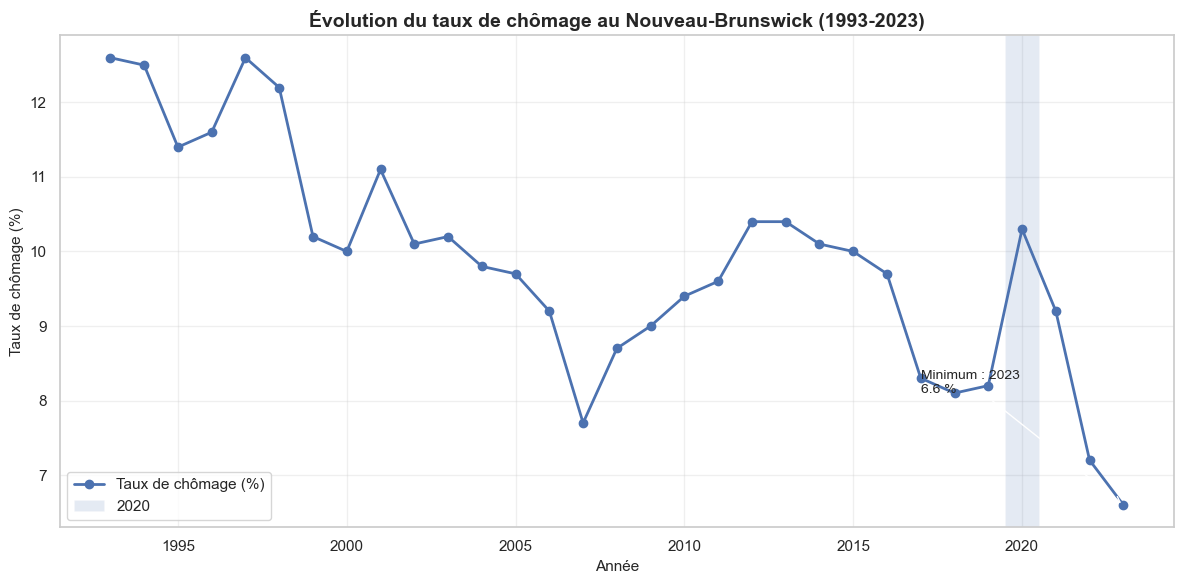

In [56]:
# Récupération des données depuis SQLite
query_chomage = """
SELECT
    annee,
    taux_chomage_pct
FROM marche_travail_nb
ORDER BY annee;
"""

df_chomage = pd.read_sql_query(query_chomage, conn)

# Création du graphique
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    df_chomage["annee"],
    df_chomage["taux_chomage_pct"],
    marker="o",
    linewidth=2,
    label="Taux de chômage (%)"
)

# Mise en évidence de 2020
ax.axvspan(
    2019.5,
    2020.5,
    alpha=0.15,
    label="2020"
)

# Recherche automatique du minimum
annee_min = df_chomage.loc[
    df_chomage["taux_chomage_pct"].idxmin()
]

ax.annotate(
    f"Minimum : {int(annee_min['annee'])}\n"
    f"{annee_min['taux_chomage_pct']:.1f} %",
    xy=(
        annee_min["annee"],
        annee_min["taux_chomage_pct"]
    ),
    xytext=(
        annee_min["annee"] - 6,
        annee_min["taux_chomage_pct"] + 1.5
    ),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

ax.set_title(
    "Évolution du taux de chômage au Nouveau-Brunswick (1993-2023)"
)
ax.set_xlabel("Année")
ax.set_ylabel("Taux de chômage (%)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "image/chomage_evolution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### 8.2 Top 10 des territoires les plus peuplés (2021)

Ce graphique compare les dix territoires les plus peuplés de la base en 2021, après exclusion des comtés (`CT`).

Cette exclusion permet d'éviter de mélanger dans le même classement les comtés et les unités géographiques qu'ils englobent.

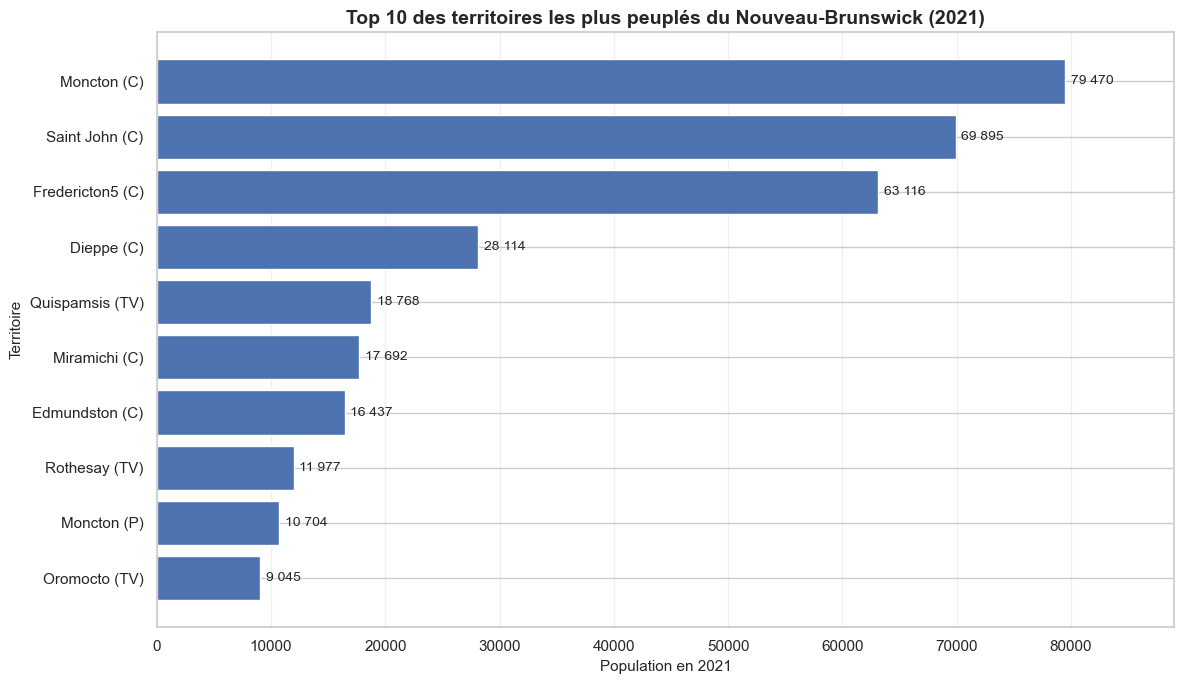

In [57]:
# Récupération des données
query_top10_pop = """
SELECT
    nom_geographique,
    type_region,
    population_2021
FROM population_logement_nb
WHERE type_region <> 'CT'
  AND population_2021 IS NOT NULL
ORDER BY population_2021 DESC
LIMIT 10;
"""

df_top10 = pd.read_sql_query(query_top10_pop, conn)

# Tri croissant pour le graphique horizontal
df_top10 = df_top10.sort_values(
    "population_2021",
    ascending=True
)

# Étiquette territoire + type
df_top10["territoire"] = (
    df_top10["nom_geographique"]
    + " ("
    + df_top10["type_region"]
    + ")"
)

# Création du graphique
fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    df_top10["territoire"],
    df_top10["population_2021"]
)

# Valeurs au bout des barres
for bar in bars:
    valeur = bar.get_width()

    ax.text(
        valeur + 500,
        bar.get_y() + bar.get_height() / 2,
        f"{int(valeur):,}".replace(",", " "),
        va="center",
        fontsize=10
    )

ax.set_title(
    "Top 10 des territoires les plus peuplés du Nouveau-Brunswick (2021)"
)
ax.set_xlabel("Population en 2021")
ax.set_ylabel("Territoire")
ax.grid(True, axis="x", alpha=0.3)

# Un peu d'espace pour afficher les valeurs
ax.set_xlim(
    0,
    df_top10["population_2021"].max() * 1.12
)

plt.tight_layout()

plt.savefig(
    "image/top10_population.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### 8.3 Évolution conjointe du chômage et du revenu total des ménages (1997-2022)

Ce graphique rapproche deux indicateurs économiques sur leur période commune : le **revenu total des ménages** et le **taux de chômage**.

Un double axe permet de visualiser simultanément leurs évolutions, malgré leurs unités différentes. Cette représentation est descriptive : elle permet de comparer les trajectoires mais ne démontre pas, à elle seule, une relation causale ou une corrélation statistique.

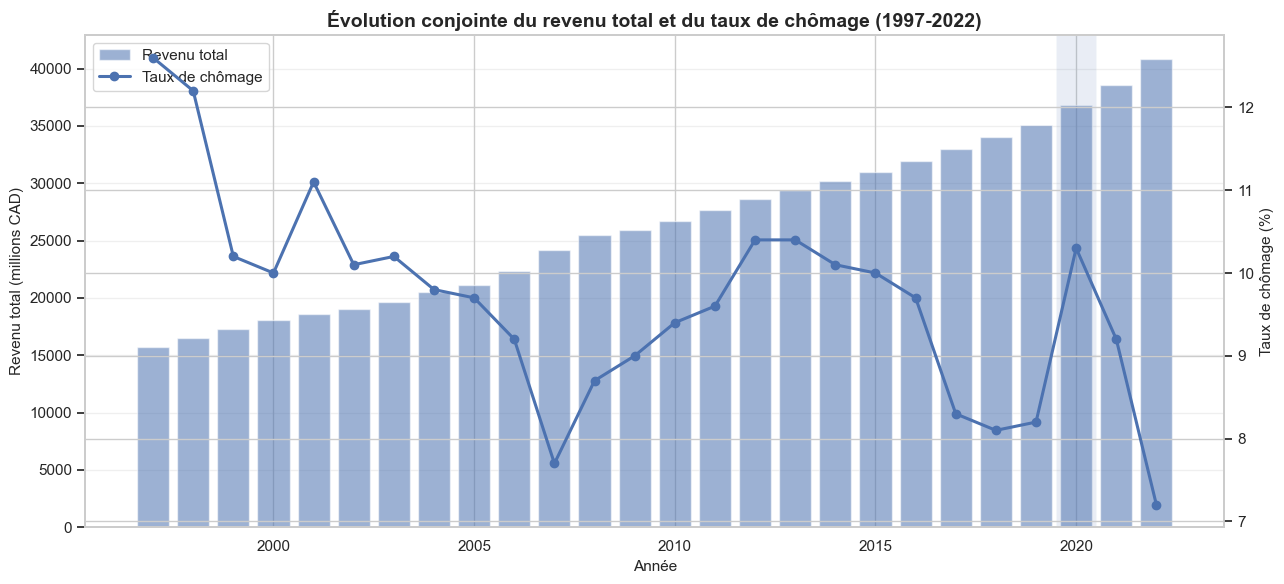

In [59]:
# Récupération des données croisées
query_croise = """
SELECT
    t.annee,
    t.taux_chomage_pct,
    r.revenu_total_millions_cad
FROM marche_travail_nb AS t
INNER JOIN revenu_menages_nb AS r
    ON t.annee = r.annee
ORDER BY t.annee;
"""

df_croise = pd.read_sql_query(query_croise, conn)

# Création du graphique
fig, ax1 = plt.subplots(figsize=(13, 6))

# Axe gauche : revenu total
bars = ax1.bar(
    df_croise["annee"],
    df_croise["revenu_total_millions_cad"],
    alpha=0.55,
    label="Revenu total"
)

ax1.set_xlabel("Année")
ax1.set_ylabel("Revenu total (millions CAD)")
ax1.grid(True, axis="y", alpha=0.3)

# Axe droit : taux de chômage
ax2 = ax1.twinx()

line, = ax2.plot(
    df_croise["annee"],
    df_croise["taux_chomage_pct"],
    marker="o",
    linewidth=2.2,
    label="Taux de chômage"
)

ax2.set_ylabel("Taux de chômage (%)")

# Mise en évidence de 2020
ax1.axvspan(
    2019.5,
    2020.5,
    alpha=0.12
)

# Légende commune
ax1.legend(
    [bars, line],
    ["Revenu total", "Taux de chômage"],
    loc="upper left"
)

ax1.set_title(
    "Évolution conjointe du revenu total et du taux de chômage (1997-2022)"
)

plt.tight_layout()

plt.savefig(
    "image/croisement_revenu_chomage.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### 8.4 Évolution de la composition du revenu des ménages (1997-2022)

Ce graphique présente l'évolution des quatre composantes disponibles du revenu des ménages :

- la rémunération des salariés ;
- le revenu mixte net ;
- le revenu de propriété reçu ;
- les transferts courants reçus.

Une représentation en **aires empilées** permet de visualiser simultanément l'évolution du niveau de chaque composante et sa contribution à l'ensemble.

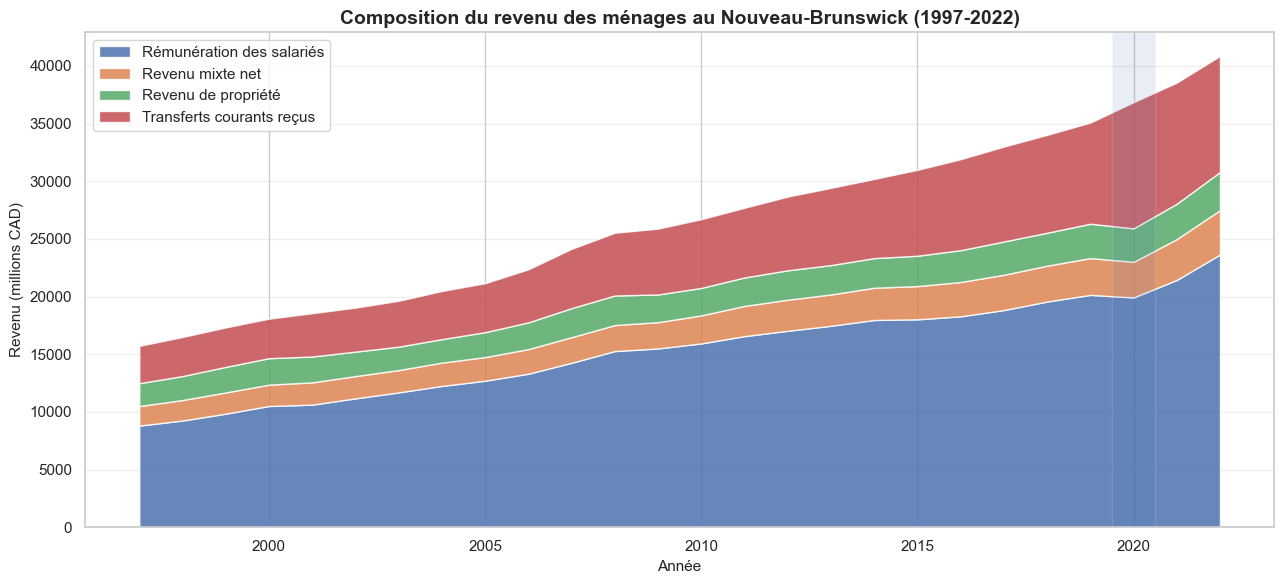

In [60]:
# Récupération des données
query_composition = """
SELECT
    annee,
    remuneration_salaries_millions_cad,
    revenu_mixte_net_millions_cad,
    revenu_propriete_recu_millions_cad,
    transferts_courants_recus_millions_cad
FROM revenu_menages_nb
ORDER BY annee;
"""

df_compo = pd.read_sql_query(query_composition, conn)

# Création du graphique
fig, ax = plt.subplots(figsize=(13, 6))

ax.stackplot(
    df_compo["annee"],
    df_compo["remuneration_salaries_millions_cad"],
    df_compo["revenu_mixte_net_millions_cad"],
    df_compo["revenu_propriete_recu_millions_cad"],
    df_compo["transferts_courants_recus_millions_cad"],
    labels=[
        "Rémunération des salariés",
        "Revenu mixte net",
        "Revenu de propriété",
        "Transferts courants reçus"
    ],
    alpha=0.85
)

# Mise en évidence de 2020
ax.axvspan(
    2019.5,
    2020.5,
    alpha=0.12
)

ax.set_title(
    "Composition du revenu des ménages au Nouveau-Brunswick (1997-2022)"
)
ax.set_xlabel("Année")
ax.set_ylabel("Revenu (millions CAD)")

ax.legend(
    loc="upper left"
)

ax.grid(
    True,
    axis="y",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "image/composition_revenu.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### 8.5 Synthèse visuelle

### 🔍 Interprétation: Visualisations

Les quatre visualisations complètent les analyses SQL en rendant immédiatement visibles plusieurs résultats importants du projet.

Le graphique du **taux de chômage** met en évidence une tendance générale à la baisse entre 1993 et 2023, malgré plusieurs fluctuations. L'année 2020 se distingue par une hausse temporaire du chômage, tandis que **2023 atteint le niveau le plus faible de la série avec 6,6 %**.

Le classement démographique montre une forte différence de taille entre les territoires. Après exclusion des comtés (`CT`), **Moncton, Saint John et Fredericton** occupent nettement les trois premières positions en 2021, devant les autres territoires du classement.

L'analyse conjointe du **revenu total et du chômage** montre que les deux indicateurs ne suivent pas simplement des trajectoires opposées. Le revenu total augmente presque continuellement entre 1997 et 2022, alors que le chômage connaît davantage de fluctuations. **2020** illustre particulièrement cette différence : le chômage augmente alors que le revenu total poursuit sa progression.

Enfin, le graphique en aires empilées montre que la **rémunération des salariés demeure la principale composante du revenu** sur toute la période. Il met également en évidence l'augmentation particulière des transferts courants en 2020, suivie d'un retour progressif vers leur niveau relatif antérieur.

Dans l'ensemble, ces visualisations permettent de transformer les résultats issus des requêtes SQL en informations plus facilement interprétables. Elles facilitent l'identification des tendances, des écarts entre territoires et des années atypiques, tout en complétant l'analyse quantitative réalisée dans les parties précédentes.

Les graphiques sont enregistrés dans le dossier `image/` afin de pouvoir être réutilisés dans la documentation du projet et dans le `README.md` du dépôt GitHub.